# Chapter 3 Lab: Fine-Tuning, Drift, and Calibration

**Runtime:** 3–4 minutes · **Difficulty:** intermediate · **Credentials:** none

This notebook treats fine-tuning as an evaluation contract rather than a training command.
It uses a chronological financial-tone task, calibrates confidence on a validation window,
measures drift, and demonstrates the parameter economics of LoRA.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/03_fine_tuning_and_calibration.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/03_fine_tuning_and_calibration.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- define train/validation/test windows by availability time;
- fit and calibrate a financial text classifier;
- compare random and chronological evaluation honestly;
- quantify parameter-efficient adaptation; and
- create a compact, auditable model card.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import hstack
from scipy.optimize import minimize_scalar
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab import canonical_hash, seed_everything
from finllm_lab.metrics import brier_score, expected_calibration_error, proportion_interval
from finllm_lab.plotting import COLORS, finish, set_finance_theme
from finllm_lab.temporal import chronological_split
from finllm_lab.text import stable_softmax

set_finance_theme()
rng = seed_everything(303)
calls = pd.read_csv(ROOT / "data" / "earnings_calls.csv", parse_dates=["available_at"])
calls = calls.sort_values("available_at").reset_index(drop=True)
tone_phrases = [
    "Management described demand as resilient and execution as strong.",
    "Management cited softer demand, execution pressure, and elevated uncertainty.",
    "Management described conditions as mixed and maintained a balanced outlook.",
]
calls["model_text"] = calls["text"]
for phrase in tone_phrases:
    calls["model_text"] = calls["model_text"].str.replace(
        phrase,
        "Management discussed execution, demand, and uncertainty.",
        regex=False,
    )
numeric_features = ["revenue_growth_pct", "margin_change_bps", "guidance_delta_pct"]
calls.groupby([calls["available_at"].dt.year, "sentiment_label"]).size().unstack(fill_value=0)


sentiment_label,negative,neutral,positive
available_at,,,
2021,0,2,10
2022,0,4,12
2023,3,8,5
2024,4,9,3
2025,0,6,10
2026,0,0,8


## 1. Freeze the temporal protocol

Validation chooses the calibration temperature. Test remains untouched until the entire
pipeline is fixed.


In [3]:
split = chronological_split(calls["available_at"], train_fraction=0.60, validation_fraction=0.20)
train = calls.iloc[split.train]
validation = calls.iloc[split.validation]
test = calls.iloc[split.test]
windows = pd.DataFrame(
    [
        ("train", train["available_at"].min(), train["available_at"].max(), len(train)),
        ("validation", validation["available_at"].min(), validation["available_at"].max(), len(validation)),
        ("test", test["available_at"].min(), test["available_at"].max(), len(test)),
    ],
    columns=["window", "first_available", "last_available", "rows"],
)
windows


,window,first_available,last_available,rows
0,train,2021-05-04 13:12:00+00:00,2024-05-05 13:12:00+00:00,50
1,validation,2024-05-06 13:12:00+00:00,2025-05-06 13:12:00+00:00,17
2,test,2025-05-07 13:12:00+00:00,2026-05-07 13:12:00+00:00,17


## 2. Fit the baseline once

The generated corpus contains a closing tone sentence that would reveal the label almost
verbatim. We neutralize that sentence to prevent a trivial shortcut, then combine TF–IDF
text features with three standardized, contemporaneously available financial metrics.


In [4]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=3000, sublinear_tf=True)
scaler = StandardScaler()
X_train = hstack(
    [vectorizer.fit_transform(train["model_text"]), scaler.fit_transform(train[numeric_features])]
)
X_val = hstack(
    [vectorizer.transform(validation["model_text"]), scaler.transform(validation[numeric_features])]
)
X_test = hstack(
    [vectorizer.transform(test["model_text"]), scaler.transform(test[numeric_features])]
)
model = LogisticRegression(max_iter=1200, class_weight="balanced", C=5.0, random_state=303)
model.fit(X_train, train["sentiment_label"])
classes = model.classes_

val_logits = model.decision_function(X_val)
test_logits = model.decision_function(X_test)
raw_test_prob = stable_softmax(test_logits, axis=1)
raw_test_pred = classes[raw_test_prob.argmax(axis=1)]
print("Classes:", classes)
print(
    "Chronological test macro-F1:",
    round(
        f1_score(
            test["sentiment_label"],
            raw_test_pred,
            labels=classes,
            average="macro",
            zero_division=0,
        ),
        3,
    ),
)


Classes: ['negative' 'neutral' 'positive']
Chronological test macro-F1: 0.478


## 3. Temperature calibration

A single positive temperature is fitted on validation log loss. It changes confidence,
not the class ranking. The untouched test window then audits whether calibration transfers.
If it does not, the release is held; we do not use the test set to switch methods.


In [5]:
class_to_index = {label: i for i, label in enumerate(classes)}
y_val = np.array([class_to_index[label] for label in validation["sentiment_label"]])
y_test = np.array([class_to_index[label] for label in test["sentiment_label"]])

def validation_nll(log_temperature: float) -> float:
    temperature = np.exp(log_temperature)
    return log_loss(y_val, stable_softmax(val_logits / temperature, axis=1), labels=np.arange(len(classes)))

solution = minimize_scalar(validation_nll, bounds=(-3, 3), method="bounded")
temperature = float(np.exp(solution.x))
cal_test_prob = stable_softmax(test_logits / temperature, axis=1)
cal_test_pred = classes[cal_test_prob.argmax(axis=1)]
print(f"Selected temperature: {temperature:.3f}")


Selected temperature: 2.056


In [6]:
def confidence_metrics(probabilities: np.ndarray, true_index: np.ndarray) -> dict:
    confidence = probabilities.max(axis=1)
    correct = (probabilities.argmax(axis=1) == true_index).astype(int)
    return {
        "accuracy": accuracy_score(true_index, probabilities.argmax(axis=1)),
        "macro_f1": f1_score(
            true_index,
            probabilities.argmax(axis=1),
            labels=np.arange(probabilities.shape[1]),
            average="macro",
            zero_division=0,
        ),
        "nll": log_loss(true_index, probabilities, labels=np.arange(probabilities.shape[1])),
        "brier_confidence": brier_score(confidence, correct),
        "ece": expected_calibration_error(confidence, correct, bins=6),
    }

comparison = pd.DataFrame(
    [confidence_metrics(raw_test_prob, y_test), confidence_metrics(cal_test_prob, y_test)],
    index=["raw", "temperature_scaled"],
).T
calibration_audit = (
    "PASS"
    if comparison.loc["nll", "temperature_scaled"] <= comparison.loc["nll", "raw"]
    else "HOLD: validation-selected temperature did not transfer to the test window"
)
print("Calibration audit:", calibration_audit)
accuracy, accuracy_low, accuracy_high = proportion_interval(
    int((cal_test_prob.argmax(axis=1) == y_test).sum()),
    len(y_test),
)
print(
    "Calibrated test accuracy Wilson interval:",
    tuple(round(value, 3) for value in (accuracy, accuracy_low, accuracy_high)),
)
comparison.round(4)


Calibration audit: HOLD: validation-selected temperature did not transfer to the test window
Calibrated test accuracy Wilson interval: (0.765, 0.527, 0.904)


,raw,temperature_scaled
accuracy,0.7647,0.7647
macro_f1,0.4778,0.4778
nll,0.3750,0.4451
brier_confidence,0.1299,0.1332
ece,0.1064,0.1625


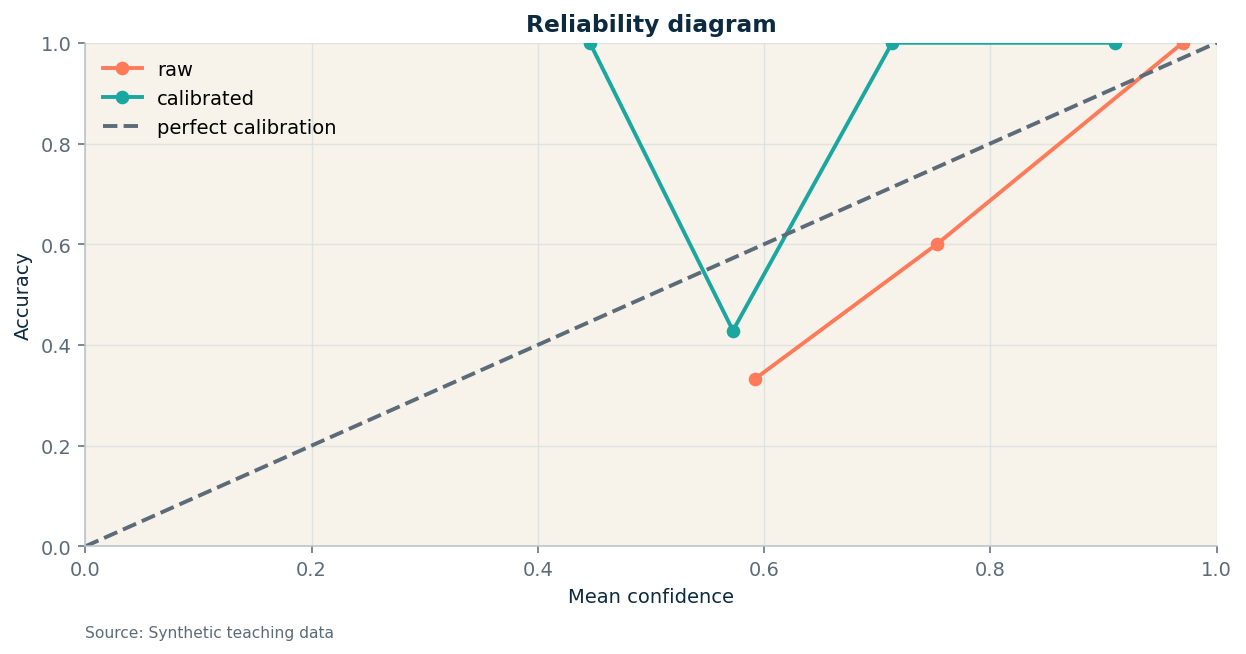

In [7]:
fig, ax = plt.subplots()
for label, probs, color in [
    ("raw", raw_test_prob, COLORS["coral"]),
    ("calibrated", cal_test_prob, COLORS["teal"]),
]:
    confidence = probs.max(axis=1)
    correct = (probs.argmax(axis=1) == y_test).astype(float)
    bins = pd.cut(confidence, bins=np.linspace(0, 1, 7), include_lowest=True)
    table = pd.DataFrame({"confidence": confidence, "correct": correct, "bin": bins}).groupby(
        "bin", observed=False
    ).agg(confidence=("confidence", "mean"), accuracy=("correct", "mean"), n=("correct", "size")).dropna()
    ax.plot(table["confidence"], table["accuracy"], marker="o", label=label, color=color)
ax.plot([0, 1], [0, 1], linestyle="--", color=COLORS["slate"], label="perfect calibration")
ax.set(xlim=(0, 1), ylim=(0, 1), title="Reliability diagram", xlabel="Mean confidence", ylabel="Accuracy")
ax.legend()
finish(ax)
plt.tight_layout()


## 4. Why random splits can mislead

The same model is evaluated with a random split. The difference is not guaranteed to
favor either protocol in every small sample; the important point is that only the
chronological result matches a forward deployment.


In [8]:
random_train, random_test = train_test_split(
    calls, test_size=len(test), random_state=303, stratify=calls["sentiment_label"]
)
rv = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=3000)
rs = StandardScaler()
rx_train = hstack(
    [rv.fit_transform(random_train["model_text"]), rs.fit_transform(random_train[numeric_features])]
)
rx_test = hstack(
    [rv.transform(random_test["model_text"]), rs.transform(random_test[numeric_features])]
)
rm = LogisticRegression(max_iter=1200, class_weight="balanced", C=5.0, random_state=303).fit(
    rx_train, random_train["sentiment_label"]
)
random_pred = rm.predict(rx_test)
pd.DataFrame(
    {
        "protocol": ["random split", "chronological split"],
        "macro_f1": [
            f1_score(
                random_test["sentiment_label"],
                random_pred,
                labels=classes,
                average="macro",
                zero_division=0,
            ),
            f1_score(
                test["sentiment_label"],
                cal_test_pred,
                labels=classes,
                average="macro",
                zero_division=0,
            ),
        ],
        "deployment_valid": [False, True],
    }
)


,protocol,macro_f1,deployment_valid
0,random split,0.670707,False
1,chronological split,0.477778,True


## 5. Drift diagnostics


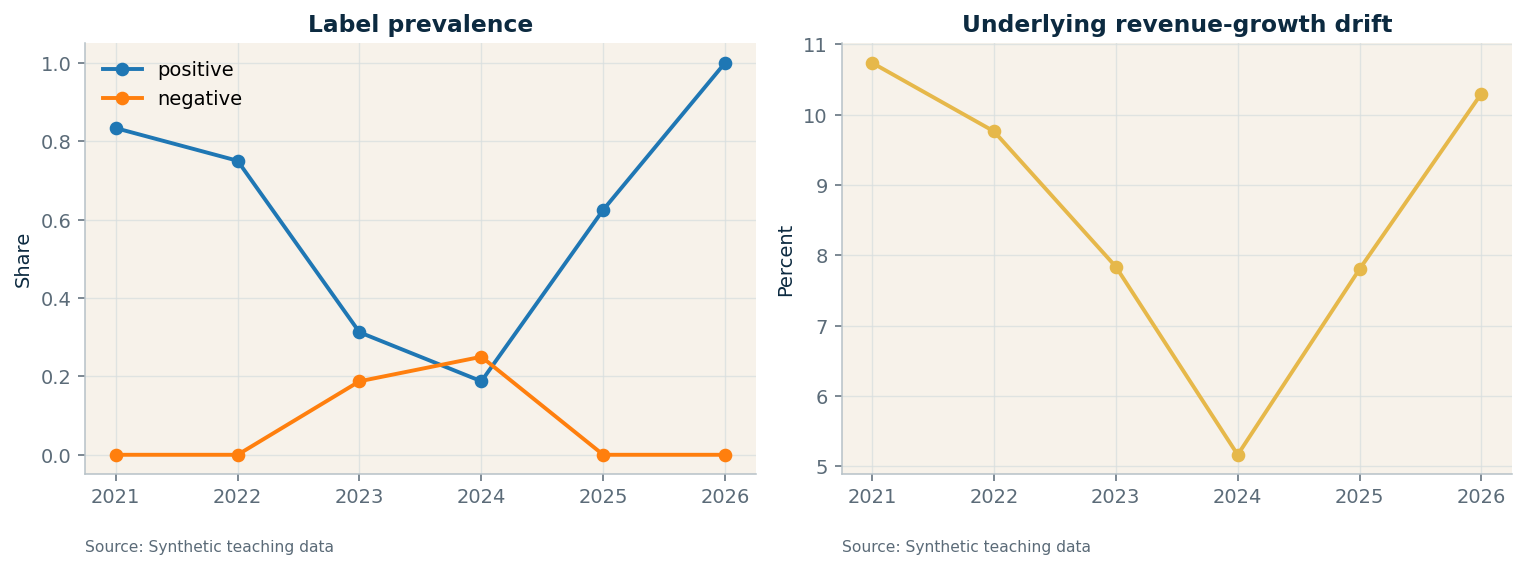

In [9]:
yearly = calls.assign(year=calls["available_at"].dt.year).groupby("year").agg(
    calls=("document_id", "size"),
    positive_share=("sentiment_label", lambda s: (s == "positive").mean()),
    negative_share=("sentiment_label", lambda s: (s == "negative").mean()),
    mean_growth=("revenue_growth_pct", "mean"),
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(yearly.index, yearly["positive_share"], marker="o", label="positive")
axes[0].plot(yearly.index, yearly["negative_share"], marker="o", label="negative")
axes[0].set(title="Label prevalence", ylabel="Share")
axes[0].legend()
axes[1].plot(yearly.index, yearly["mean_growth"], marker="o", color=COLORS["gold"])
axes[1].set(title="Underlying revenue-growth drift", ylabel="Percent")
for ax in axes:
    finish(ax)
plt.tight_layout()


## 6. LoRA parameter economics

For a frozen `d_in × d_out` matrix, a rank-`r` update trains `r(d_in+d_out)` values
instead of `d_in d_out`. Parameter counts below use a 768 × 768 layer. The SVD error is
computed on a separate 96 × 96 surrogate to keep the lab quick; it illustrates the
best rank-`r` approximation curve, not a measured LoRA training result.


In [10]:
d_in = d_out = 768
full_update = rng.normal(size=(96, 96))
u, singular, vt = np.linalg.svd(full_update, full_matrices=False)
rows = []
for rank in [2, 4, 8, 16, 32]:
    approximation = (u[:, :rank] * singular[:rank]) @ vt[:rank]
    rows.append(
        {
            "rank": rank,
            "trainable_parameters": rank * (d_in + d_out),
            "share_of_full_pct": 100 * rank * (d_in + d_out) / (d_in * d_out),
            "surrogate_svd_relative_error": (
                np.linalg.norm(full_update - approximation) / np.linalg.norm(full_update)
            ),
        }
    )
lora = pd.DataFrame(rows)
lora.round(4)


,rank,trainable_parameters,share_of_full_pct,surrogate_svd_relative_error
0,2,3072,0.5208,0.9615
1,4,6144,1.0417,0.9252
2,8,12288,2.0833,0.8574
3,16,24576,4.1667,0.7315
4,32,49152,8.3333,0.5088


## 7. Create the model card


In [11]:
model_card = {
    "model": "TF-IDF + standardized financial metrics + balanced logistic regression",
    "purpose": "fictional earnings-call tone baseline",
    "data": {
        "rows": len(calls),
        "issuers": calls["ticker"].nunique(),
        "coverage": [calls["period"].min(), calls["period"].max()],
        "status": "fictional",
    },
    "training_cutoff": train["available_at"].max().isoformat(),
    "validation_window": [validation["available_at"].min().isoformat(), validation["available_at"].max().isoformat()],
    "test_window": [test["available_at"].min().isoformat(), test["available_at"].max().isoformat()],
    "calibration_temperature": round(temperature, 6),
    "calibration_audit": calibration_audit,
    "deployment_status": "HOLD" if calibration_audit != "PASS" else "TEACHING_BENCHMARK_PASS",
    "raw_test_metrics": {
        k: round(v, 6) for k, v in confidence_metrics(raw_test_prob, y_test).items()
    },
    "calibrated_test_metrics": {
        k: round(v, 6) for k, v in confidence_metrics(cal_test_prob, y_test).items()
    },
    "accuracy_wilson_95": [round(accuracy_low, 6), round(accuracy_high, 6)],
    "prohibited_use": ["live trading", "client advice", "claims about real issuers"],
}
model_card["fingerprint"] = canonical_hash(model_card)
model_card


{'accuracy_wilson_95': [0.527382, 0.90445],
 'calibrated_test_metrics': {'accuracy': 0.764706,
                             'brier_confidence': 0.13316,
                             'ece': 0.162546,
                             'macro_f1': 0.477778,
                             'nll': 0.445148},
 'calibration_audit': 'HOLD: validation-selected temperature did not transfer to the test window',
 'calibration_temperature': 2.055797,
 'data': {'coverage': ['2021Q1', '2026Q1'], 'issuers': 4, 'rows': 84, 'status': 'fictional'},
 'deployment_status': 'HOLD',
 'fingerprint': '785b4225be3d38d1133d2e287acf74c184720b9130708d644248d1673d328a6f',
 'model': 'TF-IDF + standardized financial metrics + balanced logistic regression',
 'prohibited_use': ['live trading', 'client advice', 'claims about real issuers'],
 'purpose': 'fictional earnings-call tone baseline',
 'raw_test_metrics': {'accuracy': 0.764706,
                      'brier_confidence': 0.129894,
                      'ece': 0.106426,
   

## Takeaways

- Fine-tuning quality begins with the split and data contract, not the optimizer.
- Confidence needs independent calibration and monitoring.
- A random holdout does not reproduce a forward financial decision.
- LoRA saves parameters; it does not remove the need for temporal validation.

**Challenge:** add issuer-grouped evaluation and report the worst-issuer macro-F1 with a
bootstrap interval.
